## Imports

In [1]:
import sys
import os
import torch
import torch.utils.data as data
import torch.nn as nn

import neuro_fuzzy_toolbox as nft

## Data

In [2]:
x_train = 2 * torch.rand(200, 3) - 1
x_train

tensor([[ 0.4463, -0.6210,  0.1945],
        [ 0.4566,  0.5394,  0.1510],
        [-0.5637, -0.8054,  0.8445],
        [ 0.1156, -0.3217, -0.9140],
        [ 0.8902,  0.5671, -0.2896],
        [-0.1723, -0.8519,  0.2760],
        [-0.2812,  0.9505, -0.4199],
        [-0.4454,  0.2978, -0.6962],
        [ 0.7642, -0.3259,  0.5999],
        [-0.2143, -0.0133,  0.0082],
        [ 0.3140, -0.6718,  0.5059],
        [ 0.3340, -0.7724,  0.0637],
        [-0.4922,  0.2298,  0.1283],
        [-0.4930,  0.7137,  0.5161],
        [ 0.9753,  0.7263,  0.1605],
        [-0.0430,  0.4052, -0.1410],
        [ 0.9459,  0.2908, -0.5604],
        [ 0.8059,  0.2763,  0.7358],
        [ 0.6798, -0.4845,  0.8689],
        [ 0.3004, -0.3204,  0.6763],
        [-0.8521, -0.0526, -0.7291],
        [-0.8612,  0.9604,  0.3373],
        [ 0.2818, -0.9273, -0.3439],
        [ 0.8706, -0.0456,  0.8499],
        [ 0.8002, -0.0508,  0.3851],
        [ 0.4407,  0.2464, -0.7714],
        [ 0.4644,  0.7815,  0.6001],
 

In [3]:
y_train = torch.rand(200)
y_train

tensor([0.9975, 0.0878, 0.2190, 0.7118, 0.7853, 0.2871, 0.6240, 0.3931, 0.6150,
        0.6935, 0.4374, 0.1781, 0.1637, 0.8420, 0.2718, 0.8848, 0.9520, 0.6082,
        0.3366, 0.4662, 0.7188, 0.0013, 0.0530, 0.0462, 0.1010, 0.5142, 0.4284,
        0.1069, 0.6961, 0.9673, 0.4251, 0.3529, 0.4176, 0.6359, 0.7166, 0.1950,
        0.3561, 0.5268, 0.6369, 0.3021, 0.9904, 0.1850, 0.1178, 0.9605, 0.2844,
        0.0734, 0.5292, 0.3786, 0.8600, 0.6030, 0.9994, 0.5227, 0.7984, 0.1721,
        0.5525, 0.9349, 0.0596, 0.4258, 0.8416, 0.8444, 0.4225, 0.5328, 0.9325,
        0.6048, 0.8719, 0.2636, 0.5585, 0.1459, 0.4321, 0.7681, 0.9323, 0.4873,
        0.9779, 0.3612, 0.7655, 0.5212, 0.4895, 0.7120, 0.5266, 0.8984, 0.1034,
        0.8010, 0.9147, 0.6640, 0.8233, 0.5872, 0.0926, 0.9084, 0.7383, 0.7818,
        0.4800, 0.2698, 0.8411, 0.7067, 0.9979, 0.6416, 0.9412, 0.8888, 0.2881,
        0.9255, 0.9053, 0.9480, 0.3750, 0.6359, 0.1770, 0.5984, 0.1405, 0.1377,
        0.3821, 0.4928, 0.0480, 0.0276, 

## Model

In [4]:
model = nft.h_ANFIS(
    input_size=x_train.shape[1], # 3 features
    num_mfs=3, # 4 funciones de membresía
    outputs=1, # 1 salida
    membership_function=nft.Gaussian_MF(), # Función de membresía gaussiana
    output_type='default', # Tipo de salida: default
)

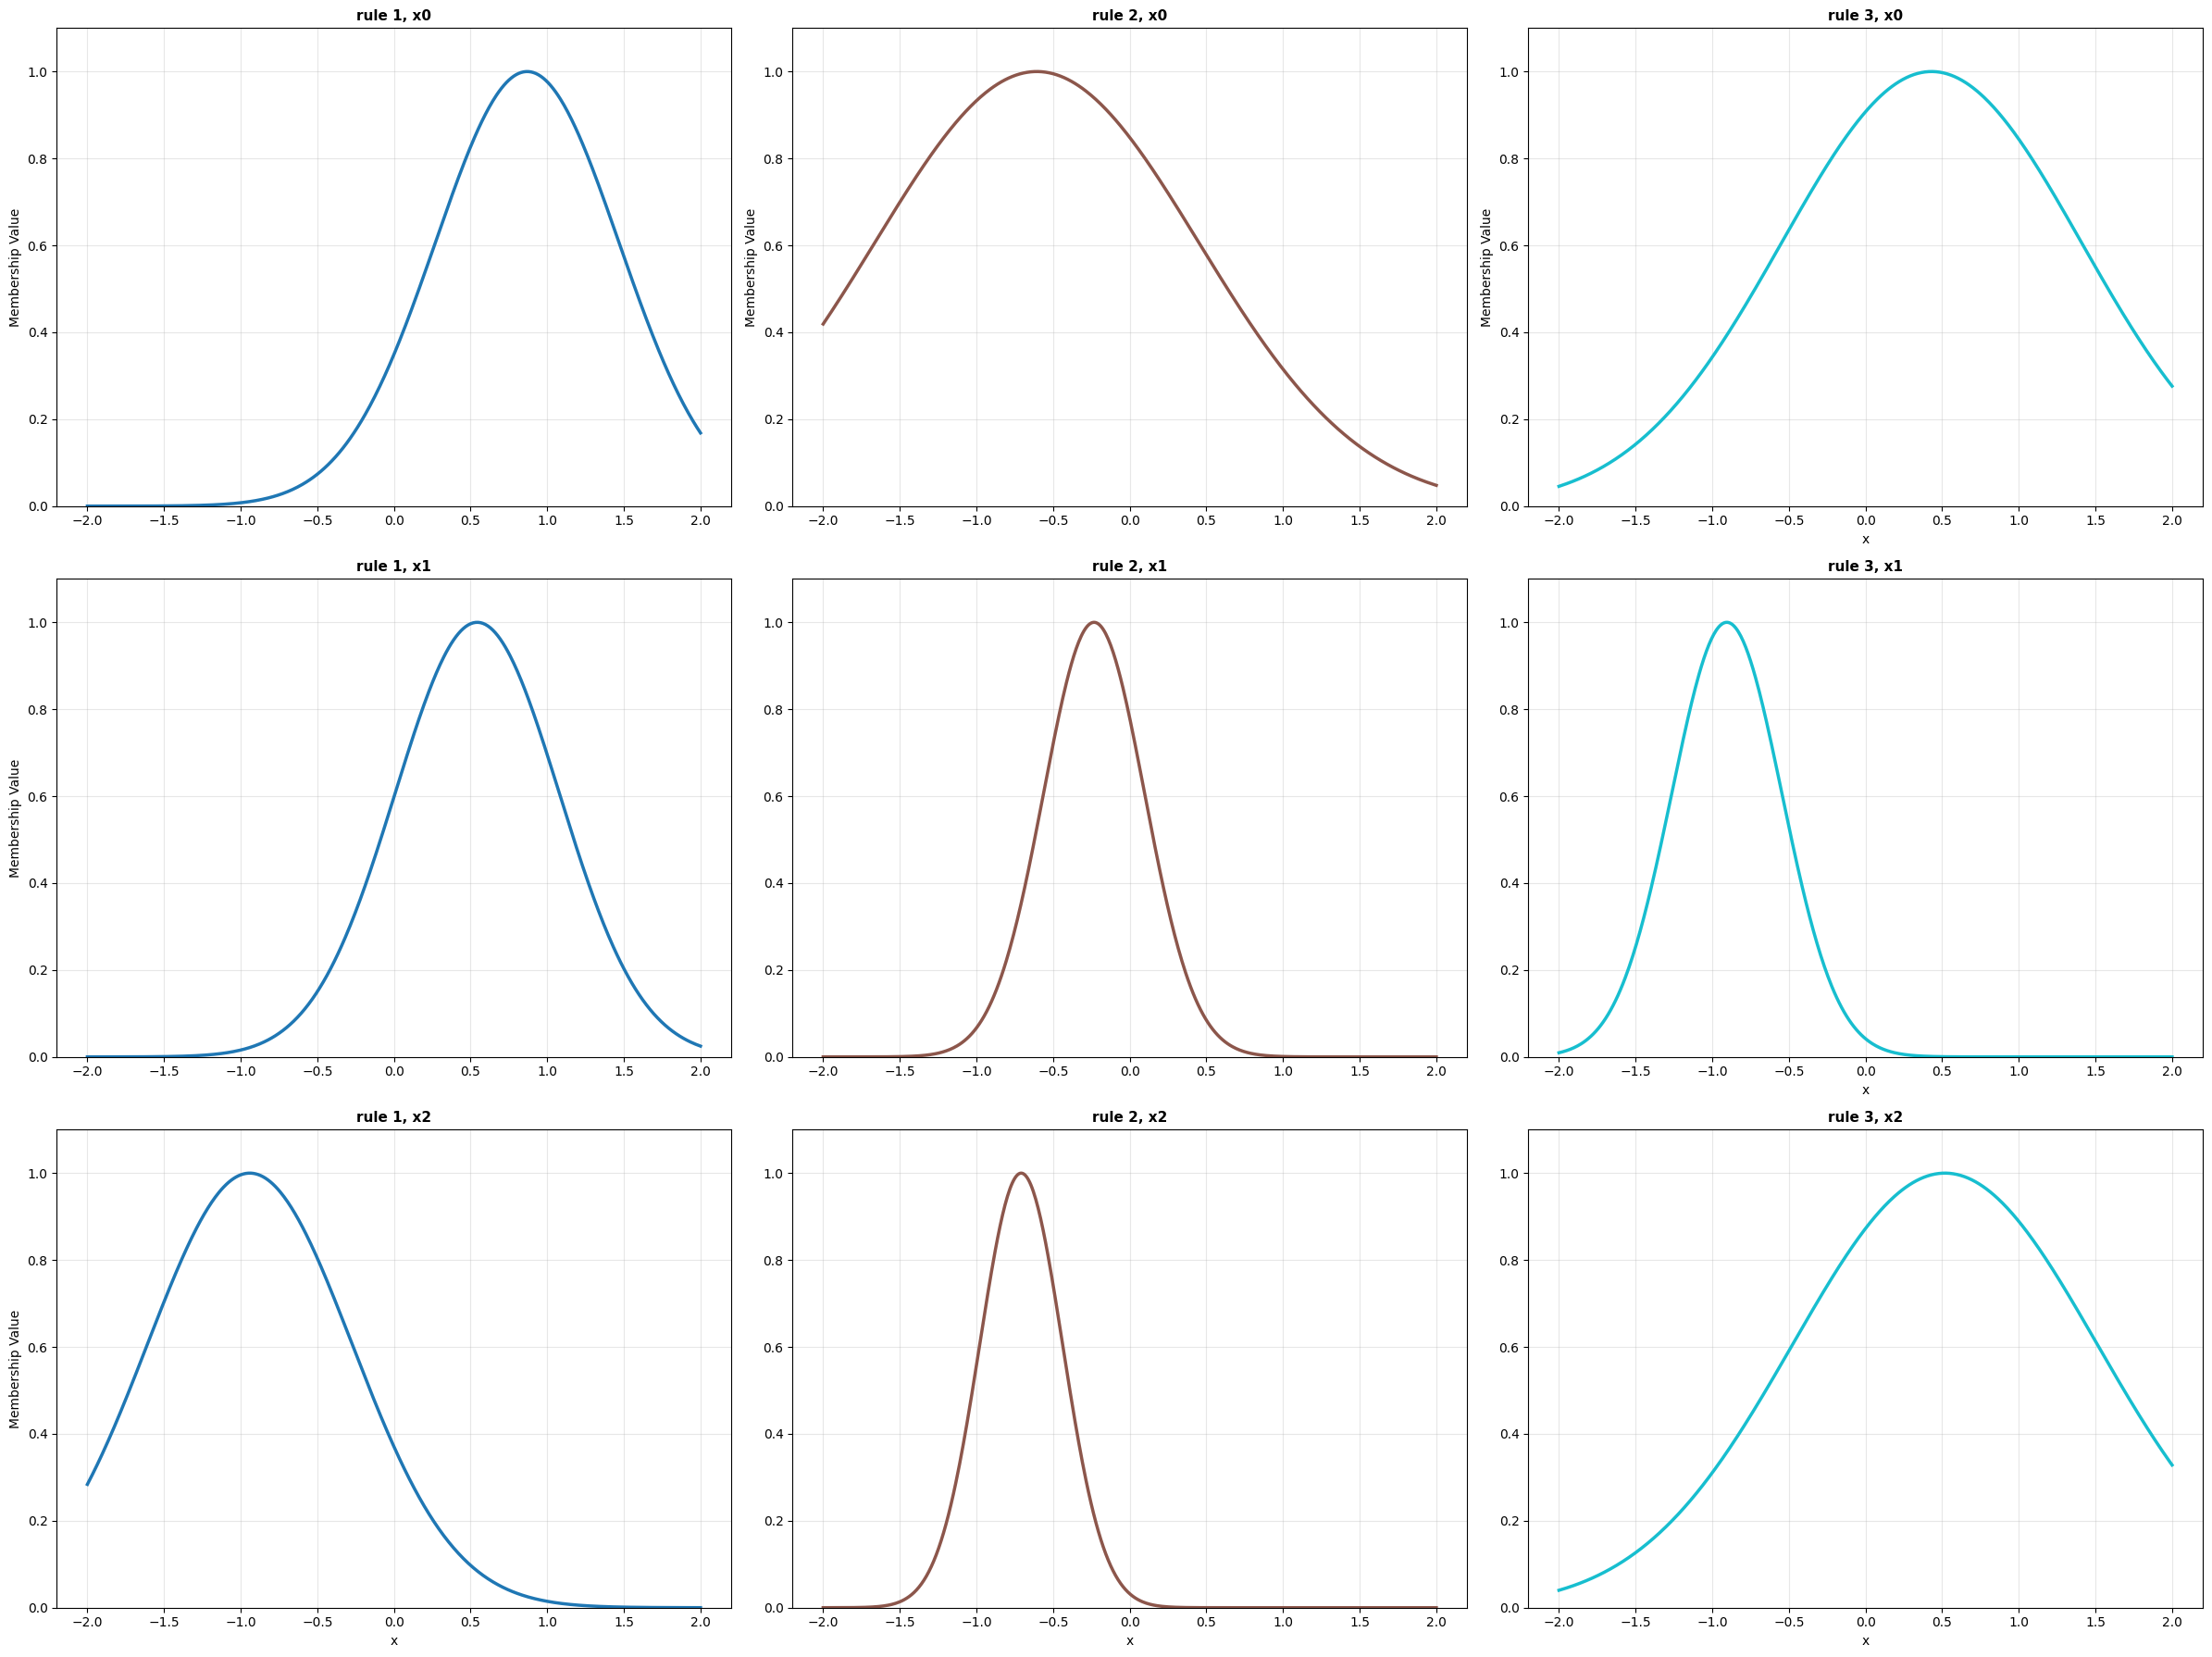

In [5]:
model.plot_premises()

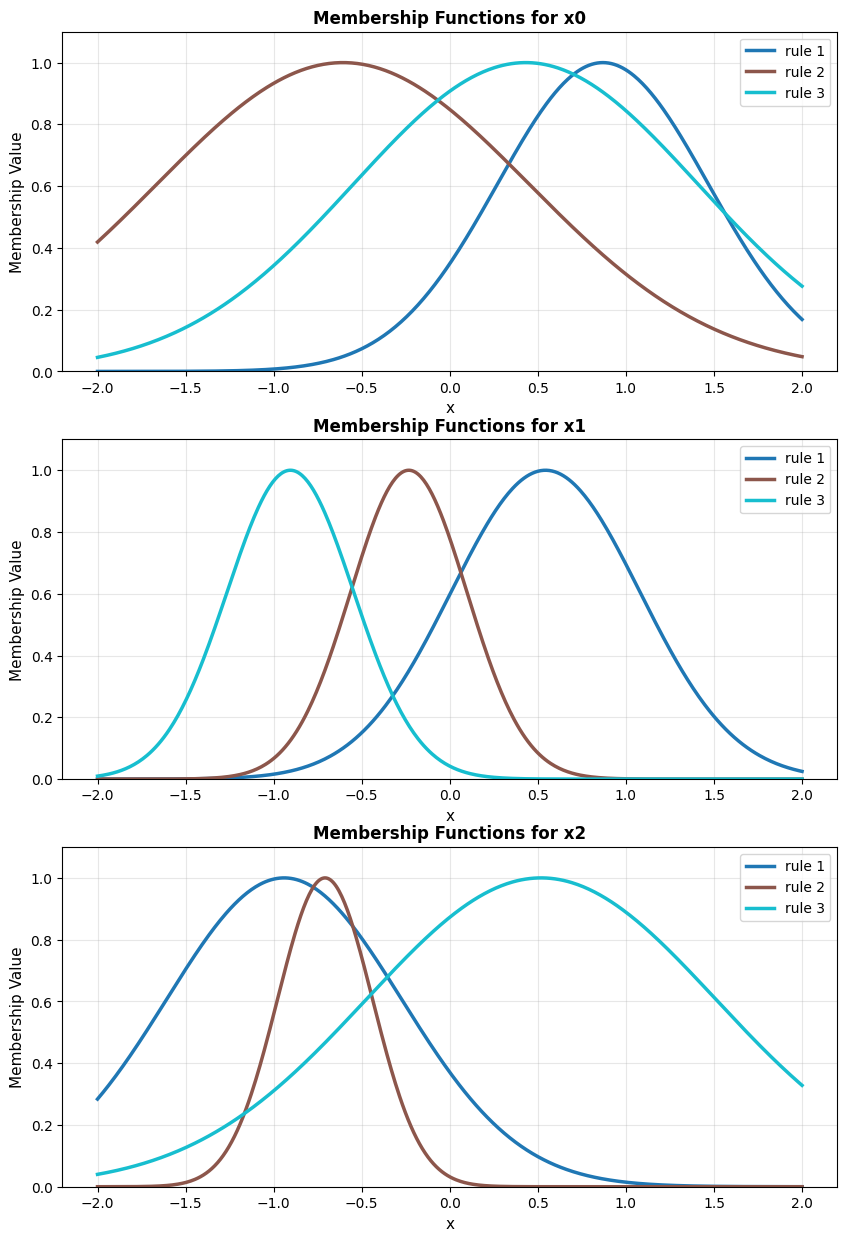

In [6]:
model.plot_premises(group_by_dim=True)

In [7]:
model.init_premises(x_train)

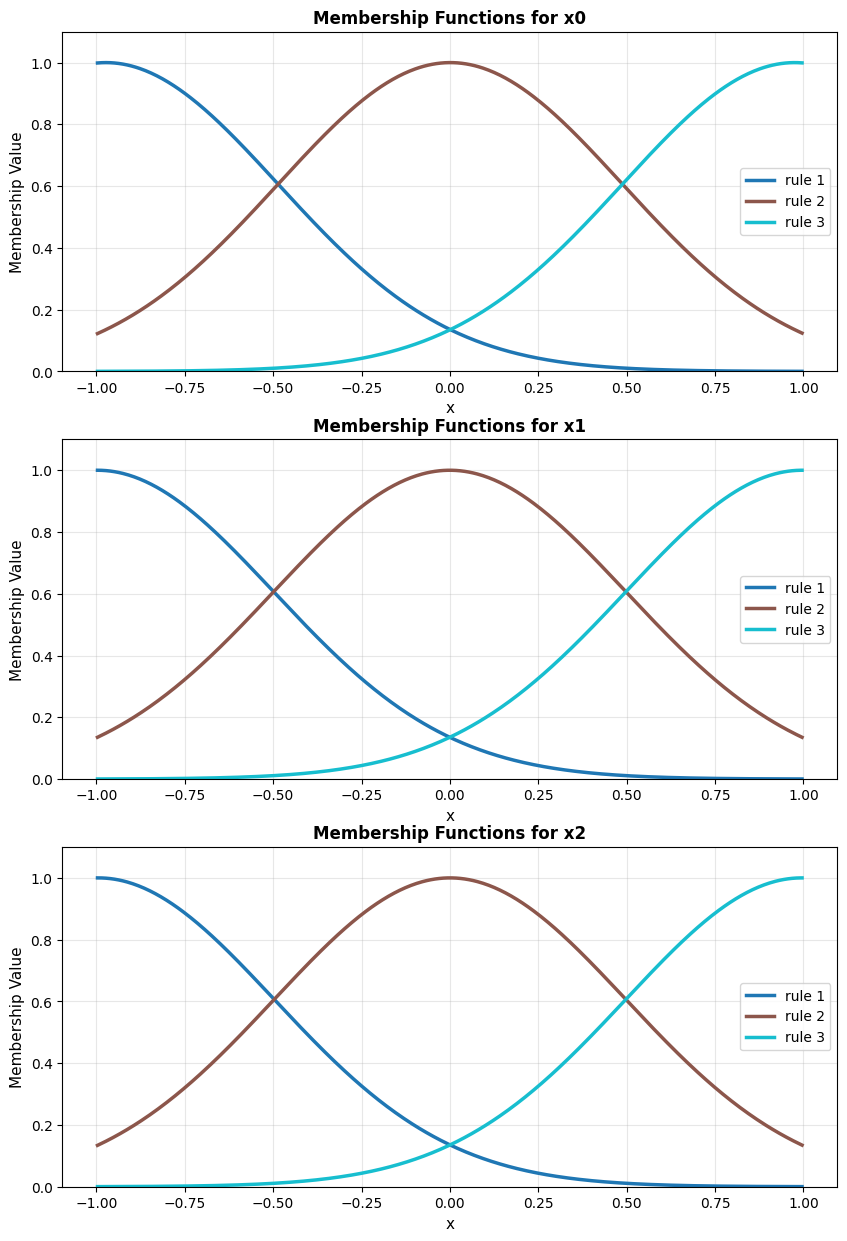

In [8]:
model.plot_premises(group_by_dim=True)

In [9]:
model.get_premises_structure()

x0                x1                  x2          
              mu   sigma        mu     sigma        mu     sigma
rule 1 -0.973055  0.4871 -0.996895  0.498293 -0.994297  0.497349
rule 2  0.001145  0.4871 -0.000309  0.498293  0.000402  0.497349
rule 3  0.975346  0.4871  0.996277  0.498293  0.995100  0.497349

In [10]:
model.get_premises()

tensor([[[-9.7306e-01,  4.8710e-01],
         [ 1.1455e-03,  4.8710e-01],
         [ 9.7535e-01,  4.8710e-01]],

        [[-9.9689e-01,  4.9829e-01],
         [-3.0911e-04,  4.9829e-01],
         [ 9.9628e-01,  4.9829e-01]],

        [[-9.9430e-01,  4.9735e-01],
         [ 4.0162e-04,  4.9735e-01],
         [ 9.9510e-01,  4.9735e-01]]])

In [11]:
model.get_consequents_structure()[0]

,x0,x1,x2,
,c0,c1,c2,c3
rule 1,-0.664952,0.969576,0.888087,-0.383714
rule 2,-0.532921,0.361064,0.114172,-0.736904
rule 3,0.143380,0.002692,0.342446,-0.557339
rule 4,0.107487,-0.288293,-0.506103,0.264028
rule 5,-0.335773,0.901906,-0.872449,0.712970
rule 6,0.910643,-0.048955,-0.572946,-0.351301
rule 7,-0.046822,0.099387,0.598566,-0.087532
rule 8,0.897434,0.167976,-0.983308,0.553635
rule 9,0.966404,0.830118,-0.501822,0.298146


In [12]:
model.init_consequents(x_train, y_train, driver="gelss", ridge_lambda=0.1)

In [13]:
model.get_consequents_structure()[0]

,x0,x1,x2,
,c0,c1,c2,c3
rule 1,-0.275896,-0.212287,-0.310595,0.277838
rule 2,0.053708,0.144930,0.103862,0.393455
rule 3,0.058993,0.206118,-0.121847,-0.018705
rule 4,-0.550650,-0.127431,-0.207464,0.240464
rule 5,-0.263482,-0.163577,-0.138457,0.279677
rule 6,-0.644375,0.124208,0.140423,0.188268
rule 7,-0.028450,0.126737,-0.044237,0.175434
rule 8,-0.091928,-0.244470,-0.133223,0.254541
rule 9,-0.568501,0.184876,0.395773,0.466186


In [14]:
model.get_rules_structure()

premises                                                  \
               x0                x1                  x2             
               mu   sigma        mu     sigma        mu     sigma   
rule 1  -0.973055  0.4871 -0.996895  0.498293 -0.994297  0.497349   
rule 2  -0.973055  0.4871 -0.996895  0.498293  0.000402  0.497349   
rule 3  -0.973055  0.4871 -0.996895  0.498293  0.995100  0.497349   
rule 4  -0.973055  0.4871 -0.000309  0.498293 -0.994297  0.497349   
rule 5  -0.973055  0.4871 -0.000309  0.498293  0.000402  0.497349   
rule 6  -0.973055  0.4871 -0.000309  0.498293  0.995100  0.497349   
rule 7  -0.973055  0.4871  0.996277  0.498293 -0.994297  0.497349   
rule 8  -0.973055  0.4871  0.996277  0.498293  0.000402  0.497349   
rule 9  -0.973055  0.4871  0.996277  0.498293  0.995100  0.497349   
rule 10  0.001145  0.4871 -0.996895  0.498293 -0.994297  0.497349   
rule 11  0.001145  0.4871 -0.996895  0.498293  0.000402  0.497349   
rule 12  0.001145  0.4871 -0.996895  0.498293  0.995100  0.497349   
rule 13  0.001145  0.4871 -0.000309  0.498293 -0.994297  0.497349   
rule 14  0.001145  0.4871 -0.000309  0.498293  0.000402  0.497349   
rule 15  0.001145  0.4871 -0.000309  0.498293  0.995100  0.497349   
rule 16  0.001145  0.4871  0.996277  0.498293 -0.994297  0.497349   
rule 17  0.001145  0.4871  0.996277  0.498293  0.000402  0.497349   
rule 18  0.001145  0.4871  0.996277  0.498293  0.995100  0.497349   
rule 19  0.975346  0.4871 -0.996895  0.498293 -0.994297  0.497349   
rule 20  0.975346  0.4871 -0.996895  0.498293  0.000402  0.497349   
rule 21  0.975346  0.4871 -0.996895  0.498293  0.995100  0.497349   
rule 22  0.975346  0.4871 -0.000309  0.498293 -0.994297  0.497349   
rule 23  0.975346  0.4871 -0.000309  0.498293  0.000402  0.497349   
rule 24  0.975346  0.4871 -0.000309  0.498293  0.995100  0.497349   
rule 25  0.975346  0.4871  0.996277  0.498293 -0.994297  0.497349   
rule 26  0.975346  0.4871  0.996277  0.498293  0.000402  0.497349   
rule 27  0.975346  0.4871  0.996277  0.498293  0.995100  0.497349   

        output 1 consequents                                
                          x0        x1        x2            
                          c0        c1        c2        c3  
rule 1             -0.275896 -0.212287 -0.310595  0.277838  
rule 2              0.053708  0.144930  0.103862  0.393455  
rule 3              0.058993  0.206118 -0.121847 -0.018705  
rule 4             -0.550650 -0.127431 -0.207464  0.240464  
rule 5             -0.263482 -0.163577 -0.138457  0.279677  
rule 6             -0.644375  0.124208  0.140423  0.188268  
rule 7             -0.028450  0.126737 -0.044237  0.175434  
rule 8             -0.091928 -0.244470 -0.133223  0.254541  
rule 9             -0.568501  0.184876  0.395773  0.466186  
rule 10             0.022711 -0.117732 -0.668891  0.046985  
rule 11            -0.615020  0.064720  0.797004  0.700039  
rule 12             0.049317 -0.383645  0.052540  0.304556  
rule 13             0.297840  0.209693 -0.076611  0.164830  
rule 14            -0.403506 -0.367777 -0.156490  0.882609  
rule 15             0.836971  0.464150  0.270792  0.370891  
rule 16             0.403411  0.345307 -0.239315  0.669848  
rule 17             0.016800 -0.000485 -0.252451  0.535706  
rule 18             0.258420 -0.009635  0.147641  0.343833  
rule 19             0.267918 -0.172566 -0.287385  0.346721  
rule 20             0.281863 -0.206221  0.026575  0.280086  
rule 21             0.154888 -0.401962  0.201611  0.291108  
rule 22             0.607551 -0.027894 -0.005262  0.679306  
rule 23             0.329015  0.020532 -0.555998  0.031949  
rule 24            -0.205568  0.420329  0.332901  0.351811  
rule 25            -0.297622  0.131640  0.337963  0.276597  
rule 26             0.134081 -0.105328 -0.308348  0.195278  
rule 27             0.180145 -0.176694  0.166458  0.347690

In [15]:
model(x_train[:10])

tensor([0.5100, 0.3906, 0.2653, 0.4716, 0.4732, 0.6821, 0.5750, 0.4942, 0.4124,
        0.6292], grad_fn=<SqueezeBackward1>)

In [16]:
with torch.no_grad():
    output = model(x_train[:10])

print(output)

tensor([0.5100, 0.3906, 0.2653, 0.4716, 0.4732, 0.6821, 0.5750, 0.4942, 0.4124,
        0.6292])


In [17]:
model.predict(x_train[:10])

tensor([0.5100, 0.3906, 0.2653, 0.4716, 0.4732, 0.6821, 0.5750, 0.4942, 0.4124,
        0.6292])

## Binary output

In [18]:
x_train = 2 * torch.rand(200, 3) - 1

In [19]:
y_train = torch.randint(0, 2, (200,))
y_train[:10]

tensor([0, 1, 0, 0, 1, 0, 1, 0, 1, 0])

In [20]:
bin_model = nft.h_ANFIS(
    input_size=x_train.shape[1], # 3 features
    num_mfs=3, # 3 funciones de membresía
    outputs=1, # 1 salida
    membership_function=nft.Gaussian_MF(), # Función de membresía gaussiana
    output_type='sigmoid', # Tipo de salida: capa sigmoide
)

In [21]:
bin_model.predict(x_train[:10])

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [22]:
bin_model(x_train[:10])

tensor([0.4362, 0.4029, 0.4495, 0.4433, 0.3494, 0.3677, 0.3597, 0.4052, 0.4669,
        0.4631], grad_fn=<SigmoidBackward0>)

## Multiclass output

In [23]:
x_train = 2 * torch.rand(200, 3) - 1

In [24]:
y_train = torch.randint(0, 4, (200,))
y_train[:10]

tensor([2, 3, 2, 0, 1, 0, 3, 1, 1, 2])

In [25]:
mul_class_model = nft.h_ANFIS(
    input_size=x_train.shape[1], # 3 features
    num_mfs=3, # 3 funciones de membresía
    outputs=4, # 4 clases
    membership_function=nft.Gaussian_MF(), # Función de membresía gaussiana
    output_type='softmax', # Tipo de salida: capa softmax
)

In [26]:
mul_class_model.predict(x_train[:10])

tensor([1, 0, 0, 2, 0, 0, 2, 0, 1, 0])

In [27]:
mul_class_model(x_train[:10])

tensor([[ 0.1767,  0.2156, -0.2630, -0.0670],
        [ 0.2092,  0.1074, -0.3046, -0.2647],
        [ 0.1516, -0.1913, -0.0046, -0.2125],
        [ 0.0345,  0.1138,  0.1357, -0.2727],
        [ 0.1954,  0.1656, -0.0399, -0.1387],
        [ 0.4594,  0.1429, -0.3766, -0.0571],
        [ 0.0045, -0.4561,  0.1126, -0.6275],
        [ 0.4478,  0.1807, -0.1166, -0.3767],
        [-0.0286,  0.2597,  0.0114,  0.2515],
        [ 0.2479, -0.1791, -0.4450,  0.0515]], grad_fn=<SqueezeBackward1>)

In [28]:
mul_class_model(x_train[:10], return_probs=True)

tensor([[0.2884, 0.2998, 0.1858, 0.2260],
        [0.3201, 0.2891, 0.1915, 0.1993],
        [0.3068, 0.2177, 0.2624, 0.2131],
        [0.2548, 0.2758, 0.2819, 0.1874],
        [0.2876, 0.2792, 0.2273, 0.2059],
        [0.3625, 0.2641, 0.1571, 0.2163],
        [0.3052, 0.1926, 0.3400, 0.1622],
        [0.3607, 0.2761, 0.2051, 0.1581],
        [0.2128, 0.2840, 0.2215, 0.2817],
        [0.3362, 0.2194, 0.1682, 0.2763]], grad_fn=<SoftmaxBackward0>)

In [29]:
mul_class_model.get_rules_structure()

premises                                                    \
               x0                  x1                  x2             
               mu     sigma        mu     sigma        mu     sigma   
rule 1   0.605753  0.457612  0.921793  0.263763 -0.365565  0.303283   
rule 2   0.605753  0.457612  0.921793  0.263763  0.997432  0.626321   
rule 3   0.605753  0.457612  0.921793  0.263763  0.061872  0.598071   
rule 4   0.605753  0.457612  0.575676  0.688656 -0.365565  0.303283   
rule 5   0.605753  0.457612  0.575676  0.688656  0.997432  0.626321   
rule 6   0.605753  0.457612  0.575676  0.688656  0.061872  0.598071   
rule 7   0.605753  0.457612 -0.400121  0.175774 -0.365565  0.303283   
rule 8   0.605753  0.457612 -0.400121  0.175774  0.997432  0.626321   
rule 9   0.605753  0.457612 -0.400121  0.175774  0.061872  0.598071   
rule 10 -0.888025  0.814584  0.921793  0.263763 -0.365565  0.303283   
rule 11 -0.888025  0.814584  0.921793  0.263763  0.997432  0.626321   
rule 12 -0.888025  0.814584  0.921793  0.263763  0.061872  0.598071   
rule 13 -0.888025  0.814584  0.575676  0.688656 -0.365565  0.303283   
rule 14 -0.888025  0.814584  0.575676  0.688656  0.997432  0.626321   
rule 15 -0.888025  0.814584  0.575676  0.688656  0.061872  0.598071   
rule 16 -0.888025  0.814584 -0.400121  0.175774 -0.365565  0.303283   
rule 17 -0.888025  0.814584 -0.400121  0.175774  0.997432  0.626321   
rule 18 -0.888025  0.814584 -0.400121  0.175774  0.061872  0.598071   
rule 19 -0.695057  0.870740  0.921793  0.263763 -0.365565  0.303283   
rule 20 -0.695057  0.870740  0.921793  0.263763  0.997432  0.626321   
rule 21 -0.695057  0.870740  0.921793  0.263763  0.061872  0.598071   
rule 22 -0.695057  0.870740  0.575676  0.688656 -0.365565  0.303283   
rule 23 -0.695057  0.870740  0.575676  0.688656  0.997432  0.626321   
rule 24 -0.695057  0.870740  0.575676  0.688656  0.061872  0.598071   
rule 25 -0.695057  0.870740 -0.400121  0.175774 -0.365565  0.303283   
rule 26 -0.695057  0.870740 -0.400121  0.175774  0.997432  0.626321   
rule 27 -0.695057  0.870740 -0.400121  0.175774  0.061872  0.598071   

        output 1 consequents                                ...  \
                          x0        x1        x2            ...   
                          c0        c1        c2        c3  ...   
rule 1             -0.950099 -0.755338 -0.126160 -0.068619  ...   
rule 2              0.113740 -0.218837 -0.873544  0.036897  ...   
rule 3              0.374471 -0.833585 -0.399489 -0.061541  ...   
rule 4             -0.470788 -0.345291  0.729280  0.855563  ...   
rule 5             -0.266273  0.461997  0.501502 -0.681762  ...   
rule 6              0.985029  0.385120 -0.484716  0.683701  ...   
rule 7             -0.731103 -0.607500 -0.215518 -0.703717  ...   
rule 8              0.449867 -0.493236  0.305476  0.287731  ...   
rule 9             -0.298515 -0.017806 -0.687256  0.412730  ...   
rule 10            -0.006762  0.616724  0.791742  0.827503  ...   
rule 11             0.382377 -0.607582 -0.327610 -0.756062  ...   
rule 12             0.457822 -0.761734  0.134483  0.663696  ...   
rule 13            -0.231169  0.772303 -0.066135  0.054480  ...   
rule 14            -0.379487  0.141627  0.257129  0.545552  ...   
rule 15             0.268473  0.500138 -0.568040  0.129979  ...   
rule 16             0.853786 -0.866875  0.767853 -0.172839  ...   
rule 17             0.493848  0.129074  0.920322  0.690593  ...   
rule 18             0.895806  0.960287  0.874220  0.693615  ...   
rule 19            -0.460721  0.471953 -0.909586  0.633412  ...   
rule 20            -0.353127 -0.887977  0.744232  0.932397  ...   
rule 21            -0.773927  0.928087 -0.472709  0.714226  ...   
rule 22            -0.515623  0.047157  0.126031  0.091905  ...   
rule 23             0.447108  0.099503  0.371968  0.661265  ...   
rule 24            -0.764036  0.224280 -0.783073 -0.374951  ...   
rule 25             0.344438 -0.884282 -0.051436  0.629767  ...   
ru

In [30]:
print(mul_class_model.get_rules_structure().to_string())

         premises                                                   output 1 consequents                               output 2 consequents                               output 3 consequents                               output 4 consequents                              
               x0                  x1                  x2                             x0        x1        x2                             x0        x1        x2                             x0        x1        x2                             x0        x1        x2          
               mu     sigma        mu     sigma        mu     sigma                   c0        c1        c2        c3                   c0        c1        c2        c3                   c0        c1        c2        c3                   c0        c1        c2        c3
rule 1   0.605753  0.457612  0.921793  0.263763 -0.365565  0.303283            -0.950099 -0.755338 -0.126160 -0.068619            -0.039711  0.030174  0.581567  0.712745             0.

## Multiple outputs

In [31]:
x_train = 2 * torch.rand(200, 2) - 1

In [32]:
model = nft.h_ANFIS(
    input_size=x_train.shape[1], # 2 features
    num_mfs=3, # 3 funciones de membresía
    outputs=2, # 2 salidas
    membership_function=nft.Gaussian_MF(), # Función de membresía gaussiana
    output_type='default', # Tipo de salida: default
)

In [33]:
model.get_consequents_structure()

[              x0        x1          
               c0        c1        c2
 rule 1 -0.691729 -0.724642  0.832954
 rule 2 -0.410801  0.159870 -0.072416
 rule 3 -0.339814  0.877537  0.930241
 rule 4 -0.862599 -0.217674  0.264634
 rule 5 -0.200961  0.832182 -0.239405
 rule 6  0.180877  0.184083 -0.260901
 rule 7  0.002342 -0.497399  0.697117
 rule 8  0.472806  0.147035  0.163089
 rule 9 -0.216141  0.420971  0.344358,
               x0        x1          
               c0        c1        c2
 rule 1  0.131927 -0.020234 -0.024813
 rule 2 -0.600842  0.508285 -0.117301
 rule 3 -0.547698  0.598716 -0.560410
 rule 4 -0.276143  0.409028  0.244319
 rule 5 -0.848532 -0.164041  0.670741
 rule 6 -0.585979  0.011057 -0.476805
 rule 7  0.643294 -0.067049  0.102189
 rule 8  0.082532  0.126587  0.494301
 rule 9  0.025436 -0.582571 -0.634386]

In [34]:
model(x_train[:10])

tensor([[ 0.0701,  0.1045],
        [ 0.4312, -0.1669],
        [ 0.0903,  0.4875],
        [-0.0338,  0.1949],
        [ 0.1065,  0.3404],
        [ 0.0739,  0.1982],
        [ 0.2672, -0.1805],
        [-0.0147,  0.2185],
        [ 0.2668,  0.0697],
        [ 0.1342,  0.3422]], grad_fn=<SqueezeBackward1>)

## Multiclass problem

In [35]:
x_train = 2 * torch.rand(200, 2) - 1 # ejemplo de datos de entrenamiento con 2 features

model = nft.h_ANFIS(
    input_size=x_train.shape[1], # 3 features
    num_mfs=2, # 2 funciones de membresía
    outputs=3, # 3 salidas
    membership_function=nft.Gaussian_MF(), # Función de membresía gaussiana
    output_type='softmax', # Tipo de salida: capa softmax
)

In [36]:
model(x_train[:10])

tensor([[ 0.1837,  0.2405,  0.5975],
        [-0.1428,  0.2987,  0.9779],
        [ 0.1563,  1.1983,  1.0643],
        [ 0.0644,  0.3874,  0.5912],
        [-0.2386,  0.3137,  1.0167],
        [ 0.1995,  0.5205,  0.0473],
        [ 0.0787,  1.0869,  1.1296],
        [-0.1792,  0.5190,  1.0011],
        [ 0.2561,  0.2444, -0.2823],
        [-0.1944,  0.5501,  1.1206]], grad_fn=<SqueezeBackward1>)

In [37]:
model(x_train[:10], return_probs=True)

tensor([[0.2800, 0.2964, 0.4236],
        [0.1779, 0.2766, 0.5455],
        [0.1584, 0.4490, 0.3927],
        [0.2454, 0.3390, 0.4156],
        [0.1601, 0.2781, 0.5618],
        [0.3089, 0.4258, 0.2653],
        [0.1515, 0.4152, 0.4333],
        [0.1596, 0.3208, 0.5196],
        [0.3888, 0.3843, 0.2269],
        [0.1464, 0.3082, 0.5453]], grad_fn=<SoftmaxBackward0>)

In [38]:
model.predict(x_train[:10])

tensor([2, 2, 1, 2, 2, 1, 2, 2, 0, 2])

# Rule Reduced

In [39]:
x_train = 2 * torch.rand(200, 2) - 1 # ejemplo de datos de entrenamiento con 2 features

In [40]:
rr_model = nft.rule_reduced_ANFIS(
    input_size=x_train.shape[1], # 2 features
    num_mfs=3, # 3 funciones de membresía
    outputs=1, # 1 salida
)

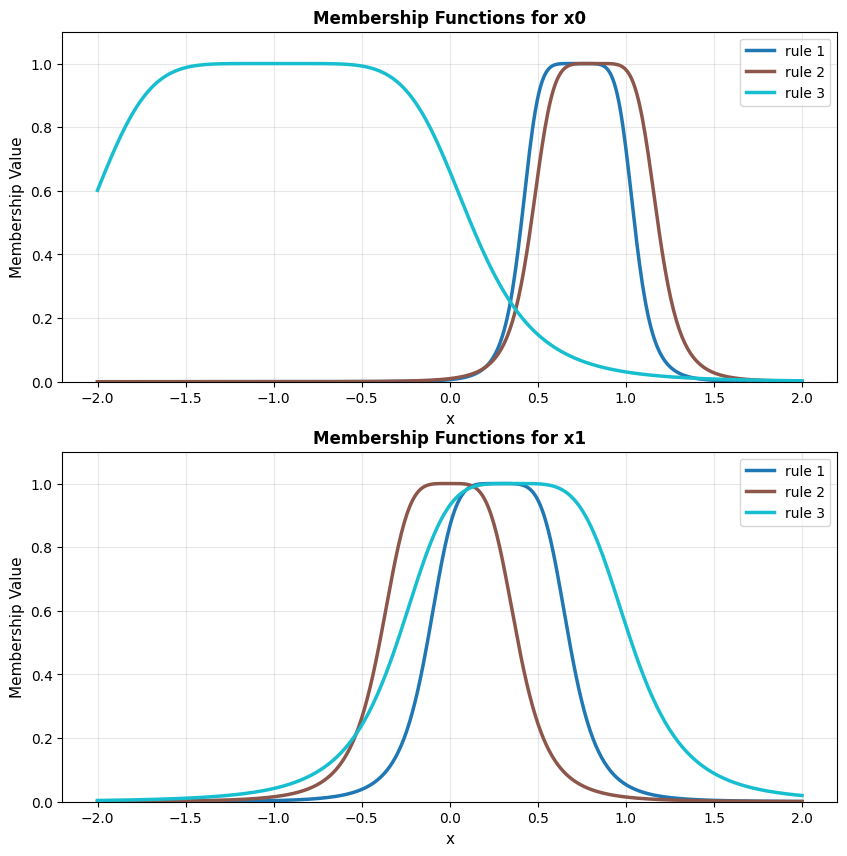

In [41]:
rr_model.plot_premises(group_by_dim=True)

In [42]:
rr_model.get_consequents_structure()[0]

,x0,x1,
,c0,c1,c2
rule 1,0.352426,-0.168166,-0.774611
rule 2,0.758635,0.545816,-0.716980
rule 3,0.015305,-0.056094,-0.060172


In [43]:
rr_model.get_rules_structure()

premises                                                    \
              x0                            x1                       
               a         b         c         a         b         c   
rule 1  0.320873  3.083321  0.727384  0.403957  2.459495  0.276516   
rule 2  0.359361  2.792343  0.821882  0.393213  2.237212  -0.00504   
rule 3  1.096495  2.925534  -0.97813  0.665708  2.182919  0.366389   

       output 1 consequents                      
                         x0        x1            
                         c0        c1        c2  
rule 1             0.352426 -0.168166 -0.774611  
rule 2             0.758635  0.545816 -0.716980  
rule 3             0.015305 -0.056094 -0.060172